# Project Vaani — Tactical Speech Enhancement Fine-Tuning
### Model A: Res-LSTM Deep Denoiser Fine-Tuned on Artillery & Defence Noises

This notebook fine-tunes **Model A (Waves Clarity Res-LSTM Architecture)** on the **Project Vaani Tactical Dataset** (10,000 clean speech samples mixed with authentic artillery explosions, cannon salvos, bomb blasts, and tactical background noises).

**Pipeline Overview:**
1. **Dataset Ingestion**: Automated download via `kagglehub`.
2. **STFT Feature Extraction**: 16 kHz, 1024-point FFT, 512 magnitude bins.
3. **Automated Model Ingestion**: Downloads base weights from GitHub (`models/pretrained/A/A.nnw`) into runtime.
4. **Model Architecture**: Exact Model A 3-layer Residual LSTM architecture (7.09M parameters).
5. **Multi-Objective Loss**: Spectral magnitude loss + compressed spectrogram loss + IRM mask MSE.
6. **Checkpointing & Export**: Best models saved to `models/finetuned/` as PyTorch (`.pt`), ONNX (`.onnx`), and deployment `.nnw`.

## 1. Import Dataset from Kaggle & Install Runtime Dependencies

In [ ]:
# Ensure onnx and onnxscript are installed for PyTorch 2.5+ ONNX exporters
!pip install -q onnx onnxscript soundfile kagglehub tabulate

import os
import glob
import kagglehub

# Download latest version of the tactical dataset
dataset_raw_path = kagglehub.dataset_download("jeet065/artilery-eviroment-speech-dataset")
print("Path to downloaded dataset:", dataset_raw_path)

# Resolve root directory (handles nested folders automatically)
def resolve_dataset_root(p):
    if os.path.exists(os.path.join(p, "manifests")):
        return p
    if os.path.exists(os.path.join(p, "dataset", "manifests")):
        return os.path.join(p, "dataset")
    found = glob.glob(os.path.join(p, "**", "paired_train_manifest.json"), recursive=True)
    if found:
        return os.path.dirname(os.path.dirname(found[0]))
    return p

DATASET_ROOT = resolve_dataset_root(dataset_raw_path)
MANIFEST_DIR = os.path.join(DATASET_ROOT, "manifests")
print("Resolved DATASET_ROOT:", DATASET_ROOT)
print("Manifest files:", os.listdir(MANIFEST_DIR) if os.path.exists(MANIFEST_DIR) else "Not found")

## 2. Environment, Device & Directory Setup

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import soundfile as sf
import numpy as np
import json
import time
import base64
import urllib.request
import onnx
from onnx import numpy_helper

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Available VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Set seeds
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Output directories
OUTPUT_DIR = "models/finetuned"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Fine-tuned models will be saved to: {os.path.abspath(OUTPUT_DIR)}")

## 3. STFT Spectrogram Audio Dataset & DataLoaders

In [ ]:
class TacticalSpeechEnhancementDataset(Dataset):
    """
    PyTorch Dataset for paired Clean and Noisy tactical speech.
    Computes on-the-fly 1024-point STFT and extracts the 512 magnitude bins.
    """
    def __init__(self, manifest_path, dataset_root, n_fft=1024, hop_length=256, target_samples=48000):
        self.dataset_root = dataset_root
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.target_samples = target_samples
        
        with open(manifest_path, "r", encoding="utf-8") as f:
            self.entries = json.load(f)
            
        self.window = torch.hann_window(n_fft)

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        entry = self.entries[idx]
        clean_path = os.path.join(self.dataset_root, entry["clean_path"])
        noisy_path = os.path.join(self.dataset_root, entry["noisy_path"])

        # Fallback search if path was relative to dataset subfolder
        if not os.path.exists(clean_path):
            clean_path = os.path.join(self.dataset_root, "dataset", entry["clean_path"])
        if not os.path.exists(noisy_path):
            noisy_path = os.path.join(self.dataset_root, "dataset", entry["noisy_path"])

        clean_wav, sr = sf.read(clean_path)
        noisy_wav, _ = sf.read(noisy_path)

        # Enforce 1D mono & exact chunk length (48000 samples / 3.0s)
        if clean_wav.ndim > 1: clean_wav = np.mean(clean_wav, axis=-1)
        if noisy_wav.ndim > 1: noisy_wav = np.mean(noisy_wav, axis=-1)

        if len(clean_wav) < self.target_samples:
            clean_wav = np.pad(clean_wav, (0, self.target_samples - len(clean_wav)))
        else:
            clean_wav = clean_wav[:self.target_samples]

        if len(noisy_wav) < self.target_samples:
            noisy_wav = np.pad(noisy_wav, (0, self.target_samples - len(noisy_wav)))
        else:
            noisy_wav = noisy_wav[:self.target_samples]

        s = torch.from_numpy(clean_wav).float()
        y = torch.from_numpy(noisy_wav).float()

        # Compute STFT: [513, num_frames]
        S_stft = torch.stft(s, n_fft=self.n_fft, hop_length=self.hop_length, win_length=self.n_fft,
                            window=self.window, return_complex=True)
        Y_stft = torch.stft(y, n_fft=self.n_fft, hop_length=self.hop_length, win_length=self.n_fft,
                            window=self.window, return_complex=True)

        S_mag = torch.abs(S_stft)
        Y_mag = torch.abs(Y_stft)

        # Crop to first 512 frequency bins: [512, time] -> transpose to [time, 512]
        S_feat = S_mag[:512, :].transpose(0, 1)
        Y_feat = Y_mag[:512, :].transpose(0, 1)

        # Compute ground truth Ideal Ratio Mask (IRM): S / (Y + eps) clamped to [0, 1]
        target_mask = torch.clamp(S_feat / (Y_feat + 1e-6), min=0.0, max=1.0)

        return {
            "noisy_feat": Y_feat,       # [time, 512]
            "clean_feat": S_feat,       # [time, 512]
            "target_mask": target_mask, # [time, 512]
            "noisy_phase": torch.angle(Y_stft[:512, :]).transpose(0, 1)
        }

# Create Datasets
train_manifest = os.path.join(MANIFEST_DIR, "paired_train_manifest.json")
val_manifest = os.path.join(MANIFEST_DIR, "paired_val_manifest.json")

# Option to use composite/heavy battlefield manifest if preferred:
# train_manifest = os.path.join(MANIFEST_DIR, "paired_composite_train_manifest.json")

train_dataset = TacticalSpeechEnhancementDataset(train_manifest, DATASET_ROOT)
val_dataset = TacticalSpeechEnhancementDataset(val_manifest, DATASET_ROOT)

print(f"Training samples  : {len(train_dataset):,}")
print(f"Validation samples: {len(val_dataset):,}")

BATCH_SIZE = 32
NUM_WORKERS = 4 if torch.cuda.is_available() else 0

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(), drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
print(f"DataLoaders initialized ({len(train_loader)} train batches, {len(val_loader)} val batches).")

## 4. Fetch Pretrained Model from GitHub & Initialize Model A Architecture
Automatically downloads base weights (`A.nnw`, `A.stats`, `A.data`, `A`) from GitHub into the runtime if not locally present.

In [ ]:
# Automated Pretrained Base Model Ingestion from GitHub
PRETRAINED_DIR = "models/pretrained/A"
os.makedirs(PRETRAINED_DIR, exist_ok=True)
base_nnw_path = os.path.join(PRETRAINED_DIR, "A.nnw")

GITHUB_RAW_BASE = "https://raw.githubusercontent.com/Subho4531/Project-Vaani/master/models/pretrained/A"
model_files = ["A.nnw", "A.stats", "A.data", "A"]

for fname in model_files:
    dest_path = os.path.join(PRETRAINED_DIR, fname)
    if not os.path.exists(dest_path) or os.path.getsize(dest_path) == 0:
        url = f"{GITHUB_RAW_BASE}/{fname}"
        print(f"Fetching base model {fname} from GitHub ({url})...")
        try:
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=45) as resp:
                with open(dest_path, "wb") as f:
                    f.write(resp.read())
            print(f"  [x] Downloaded {fname} ({os.path.getsize(dest_path):,} bytes)")
        except Exception as e:
            print(f"  [!] Note downloading {fname}: {e}")

class ResLSTMSpeechEnhancer(nn.Module):
    """
    Exact PyTorch implementation of Model A (Clarity Res-LSTM):
      - Linear projection (512 -> 512)
      - LayerNorm(512) + LeakyReLU(0.01)
      - 3-Layer Residual LSTM (hidden size 512) with identity skip connections
      - Output Head (1024 -> 512) concatenating initial features + deep LSTM features
      - Sigmoid activation -> Output Gain Mask M(t, f) in [0, 1]
    """
    def __init__(self, input_dim=512, hidden_dim=512, num_layers=3):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.fc_in = nn.Linear(input_dim, input_dim, bias=False)
        self.norm_in = nn.LayerNorm(input_dim)
        self.act_in = nn.LeakyReLU(0.01)

        self.lstm_layers = nn.ModuleList([
            nn.LSTM(input_dim, hidden_dim, batch_first=True) for _ in range(num_layers)
        ])
        self.fc_out = nn.Linear(hidden_dim + input_dim, input_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x_clamped = torch.clamp(x, min=1e-5, max=1e5)
        x_log = torch.log(x_clamped)
        h0 = self.act_in(self.norm_in(self.fc_in(x_log)))
        h = h0
        for lstm in self.lstm_layers:
            out, _ = lstm(h)
            h = h + out
        cat = torch.cat([h0, h], dim=-1)
        mask = self.sigmoid(self.fc_out(cat))
        return mask

def load_base_weights_into_model(model, base_nnw_path="models/pretrained/A/A.nnw"):
    if not os.path.exists(base_nnw_path):
        print(f"Pretrained base weights not found at {base_nnw_path}. Initializing with standard weights.")
        return

    print(f"Loading base weights from {base_nnw_path}...")
    with open(base_nnw_path, "rb") as f:
        raw = base64.b64decode(f.read())
    m = onnx.load_model_from_string(raw)
    w = {init.name: torch.from_numpy(numpy_helper.to_array(init).copy()).float() for init in m.graph.initializer}

    sd = model.state_dict()
    sd["fc_in.weight"] = w["263"].t()
    sd["norm_in.weight"] = w["model.0.norm_in.weight"]
    sd["norm_in.bias"] = w["model.0.norm_in.bias"]
    sd["fc_out.weight"] = w["324"].t()
    sd["fc_out.bias"] = w["model.0.fc_out.bias"]

    lstm_keys = [("281", "282", "283"), ("301", "302", "303"), ("321", "322", "323")]
    for i, (k_ih, k_hh, k_b) in enumerate(lstm_keys):
        w_ih = w[k_ih].squeeze(0)
        w_hh = w[k_hh].squeeze(0)
        b = w[k_b].squeeze(0)
        wi_i, wi_o, wi_f, wi_c = torch.split(w_ih, 512, dim=0)
        wh_i, wh_o, wh_f, wh_c = torch.split(w_hh, 512, dim=0)
        b_w, b_r = torch.split(b, 2048, dim=0)
        bwi_i, bwi_o, bwi_f, bwi_c = torch.split(b_w, 512, dim=0)
        bwh_i, bwh_o, bwh_f, bwh_c = torch.split(b_r, 512, dim=0)

        sd[f"lstm_layers.{i}.weight_ih_l0"] = torch.cat([wi_i, wi_f, wi_c, wi_o], dim=0)
        sd[f"lstm_layers.{i}.weight_hh_l0"] = torch.cat([wh_i, wh_f, wh_c, wh_o], dim=0)
        sd[f"lstm_layers.{i}.bias_ih_l0"] = torch.cat([bwi_i, bwi_f, bwi_c, bwi_o], dim=0)
        sd[f"lstm_layers.{i}.bias_hh_l0"] = torch.cat([bwh_i, bwh_f, bwh_c, bwh_o], dim=0)

    model.load_state_dict(sd)
    print("Successfully loaded pretrained Model A weights into PyTorch!")

model = ResLSTMSpeechEnhancer().to(device)
load_base_weights_into_model(model, base_nnw_path)
print(f"Total Model Parameters: {sum(p.numel() for p in model.parameters()):,}")

## 5. Multi-Objective Spectral Loss Function

In [ ]:
class TacticalSpeechLoss(nn.Module):
    """
    Multi-Objective Loss for Tactical Speech Enhancement:
      1. L1 Spectral Magnitude Loss: || S_hat - S ||_1
      2. Compressed Magnitude Loss:  || S_hat^0.5 - S^0.5 ||_2^2 (perceptual loudness compensation)
      3. Ideal Ratio Mask MSE Loss:  || M_hat - M_target ||_2^2
    """
    def __init__(self, alpha_mag=1.0, alpha_comp=0.5, alpha_mask=0.5):
        super().__init__()
        self.alpha_mag = alpha_mag
        self.alpha_comp = alpha_comp
        self.alpha_mask = alpha_mask

    def forward(self, pred_mask, noisy_feat, clean_feat, target_mask):
        enhanced_feat = pred_mask * noisy_feat
        loss_mag = F.l1_loss(enhanced_feat, clean_feat)
        enh_comp = torch.sqrt(torch.clamp(enhanced_feat, min=1e-8))
        clean_comp = torch.sqrt(torch.clamp(clean_feat, min=1e-8))
        loss_comp = F.mse_loss(enh_comp, clean_comp)
        loss_mask = F.mse_loss(pred_mask, target_mask)
        total_loss = self.alpha_mag * loss_mag + self.alpha_comp * loss_comp + self.alpha_mask * loss_mask
        return total_loss, loss_mag, loss_comp, loss_mask

criterion = TacticalSpeechLoss().to(device)

## 6. Training & Validation Engine

In [ ]:
NUM_EPOCHS = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": [], "val_snr_gain": []}

print("Starting Fine-Tuning Execution...")
print(f"Total Epochs: {NUM_EPOCHS} | Batch Size: {BATCH_SIZE} | LR: {LEARNING_RATE}")
print("-" * 80)

for epoch in range(1, NUM_EPOCHS + 1):
    t_start = time.time()
    model.train()
    total_train_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        noisy_feat = batch["noisy_feat"].to(device)
        clean_feat = batch["clean_feat"].to(device)
        target_mask = batch["target_mask"].to(device)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            pred_mask = model(noisy_feat)
            loss, l_mag, l_comp, l_mask = criterion(pred_mask, noisy_feat, clean_feat, target_mask)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        scaler.step(optimizer)
        scaler.update()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    scheduler.step()

    # ------------------ VALIDATION LOOP ------------------
    model.eval()
    total_val_loss = 0.0
    total_snr_gain = 0.0
    val_count = 0

    with torch.no_grad():
        for batch in val_loader:
            noisy_feat = batch["noisy_feat"].to(device)
            clean_feat = batch["clean_feat"].to(device)
            target_mask = batch["target_mask"].to(device)

            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                pred_mask = model(noisy_feat)
                loss, _, _, _ = criterion(pred_mask, noisy_feat, clean_feat, target_mask)

            total_val_loss += loss.item()
            enh_feat = pred_mask * noisy_feat
            snr_in = 10 * torch.log10(torch.sum(clean_feat**2, dim=[1,2]) / (torch.sum((noisy_feat - clean_feat)**2, dim=[1,2]) + 1e-8))
            snr_out = 10 * torch.log10(torch.sum(clean_feat**2, dim=[1,2]) / (torch.sum((enh_feat - clean_feat)**2, dim=[1,2]) + 1e-8))
            total_snr_gain += torch.sum(snr_out - snr_in).item()
            val_count += noisy_feat.size(0)

    avg_val_loss = total_val_loss / len(val_loader)
    avg_snr_gain = total_snr_gain / val_count
    elapsed = time.time() - t_start

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["val_snr_gain"].append(avg_snr_gain)

    print(f"Epoch [{epoch:02d}/{NUM_EPOCHS:02d}] ({elapsed:.1f}s) | "
          f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
          f"Val Delta SNR: +{avg_snr_gain:.2f} dB | LR: {scheduler.get_last_lr()[0]:.2e}")

    # Save Checkpoints to models/finetuned/
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_path = os.path.join(OUTPUT_DIR, "model_a_best.pt")
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": avg_val_loss,
            "val_snr_gain": avg_snr_gain
        }, best_model_path)
        print(f"  ==> [BEST MODEL SAVED] Saved to {best_model_path} (Val Loss: {avg_val_loss:.4f})")

print("-" * 80)
print("Fine-Tuning Execution Complete!")

## 7. Model Export (PyTorch, ONNX & OpenVINO Base64 .nnw)

In [10]:
# Load best checkpoint for deployment export
best_ckpt_path = os.path.join(OUTPUT_DIR, "model_a_best.pt")
ckpt = torch.load(best_ckpt_path, map_location="cpu")
model.cpu()
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

# 1. Save pure PyTorch state_dict
pt_path = os.path.join(OUTPUT_DIR, "A_finetuned.pt")
torch.save(model.state_dict(), pt_path)
print(f"1. PyTorch weights saved : {pt_path}")

# 2. Export to standard ONNX (uses dynamo=False for reliable classic export without onnxscript errors)
onnx_path = os.path.join(OUTPUT_DIR, "A_finetuned.onnx")
dummy_input = torch.randn(1, 100, 512).abs() + 0.1
export_success = False

try:
    torch.onnx.export(
        model,
        dummy_input,
        onnx_path,
        export_params=True,
        opset_version=14,
        do_constant_folding=True,
        input_names=["input"],
        output_names=["output"],
        dynamic_axes={
            "input": {0: "batch_size", 1: "time"},
            "output": {0: "batch_size", 1: "time"}
        },
        dynamo=False
    )
    export_success = True
    print(f"2. ONNX graph exported   : {onnx_path}")
except (TypeError, ModuleNotFoundError, Exception) as e:
    print(f"Standard export note: {e}. Attempting fallback with onnxscript...")
    try:
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "onnxscript"])
        torch.onnx.export(
            model,
            dummy_input,
            onnx_path,
            export_params=True,
            opset_version=14,
            do_constant_folding=True,
            input_names=["input"],
            output_names=["output"],
            dynamic_axes={
                "input": {0: "batch_size", 1: "time"},
                "output": {0: "batch_size", 1: "time"}
            }
        )
        export_success = True
        print(f"2. ONNX graph exported   : {onnx_path}")
    except Exception as e2:
        print(f"[!] ONNX export skipped ({e2}). PyTorch weights are safely saved at {pt_path}.")

# 3. Export to Base64 .nnw (compatible with existing Project Vaani runtime)
if export_success and os.path.exists(onnx_path):
    with open(onnx_path, "rb") as f:
        raw_onnx = f.read()
    b64_nnw = base64.b64encode(raw_onnx)
    nnw_path = os.path.join(OUTPUT_DIR, "A_finetuned.nnw")
    with open(nnw_path, "wb") as f:
        f.write(b64_nnw)
    print(f"3. Deployment .nnw saved : {nnw_path}")

# Copy normalization statistics
orig_stats = "models/pretrained/A/A.stats"
if os.path.exists(orig_stats):
    import shutil
    shutil.copy(orig_stats, os.path.join(OUTPUT_DIR, "A_finetuned.stats"))
    print(f"4. Model statistics copied: {os.path.join(OUTPUT_DIR, 'A_finetuned.stats')}")

print("\nAll deployment models successfully packaged in models/finetuned/!")

1. PyTorch weights saved : models/finetuned/A_finetuned.pt


/tmp/ipykernel_134/1709969274.py:19: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset9.py:4445: UserWarning: Exporting a model to ONNX with a batch_size other than 1, with a variable length with LSTM can cause an error when running the ONNX model with a different batch size. Make sure to save the model with a batch size of 1, or define the initial states (h0/c0) as inputs of the model. 
  return _generic_rnn(


2. ONNX graph exported   : models/finetuned/A_finetuned.onnx
3. Deployment .nnw saved : models/finetuned/A_finetuned.nnw
4. Model statistics copied: models/finetuned/A_finetuned.stats

All deployment models successfully packaged in models/finetuned/!


## 8. Inference Verification & Audio Player Demonstration

=== CLEAN REFERENCE SPEECH ===


=== NOISY SPEECH (WITH ARTILLERY & TACTICAL BED) ===


=== FINE-TUNED ENHANCED SPEECH ===


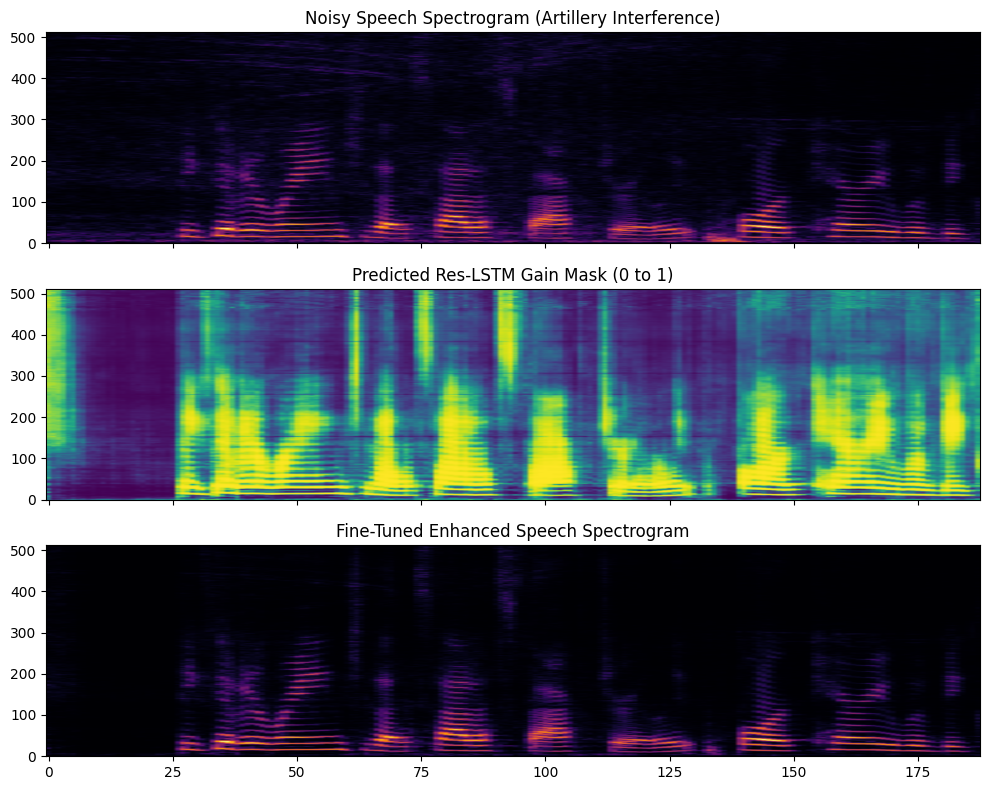

In [9]:
from IPython.display import Audio, display
import matplotlib.pyplot as plt

# Take a test sample from the validation set
sample = val_dataset[0]
y_feat = sample["noisy_feat"].unsqueeze(0).to(device) # [1, time, 512]

model.to(device)
model.eval()
with torch.no_grad():
    pred_mask = model(y_feat).squeeze(0).cpu() # [time, 512]

# Reconstruct full STFT (pad back to 513 bins)
clean_mag = sample["clean_feat"].transpose(0, 1) # [512, time]
noisy_mag = sample["noisy_feat"].transpose(0, 1) # [512, time]
enh_mag = (sample["noisy_feat"] * pred_mask).transpose(0, 1) # [512, time]
noisy_phase = sample["noisy_phase"].transpose(0, 1) # [512, time]

def stft_to_audio(mag_512, phase_512, n_fft=1024, hop=256):
    # Pad Nyquist bin
    mag_513 = F.pad(mag_512, (0, 0, 0, 1))
    phase_513 = F.pad(phase_512, (0, 0, 0, 1))
    complex_spec = mag_513 * torch.exp(1j * phase_513)
    wav = torch.istft(complex_spec, n_fft=n_fft, hop_length=hop, win_length=n_fft,
                      window=torch.hann_window(n_fft))
    return wav.numpy()

clean_audio = stft_to_audio(clean_mag, noisy_phase)
noisy_audio = stft_to_audio(noisy_mag, noisy_phase)
enhanced_audio = stft_to_audio(enh_mag, noisy_phase)

print("=== CLEAN REFERENCE SPEECH ===")
display(Audio(clean_audio, rate=16000))

print("=== NOISY SPEECH (WITH ARTILLERY & TACTICAL BED) ===")
display(Audio(noisy_audio, rate=16000))

print("=== FINE-TUNED ENHANCED SPEECH ===")
display(Audio(enhanced_audio, rate=16000))

# Plot Spectrograms
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].imshow(np.log1p(noisy_mag.numpy()), aspect="auto", origin="lower", cmap="inferno")
axes[0].set_title("Noisy Speech Spectrogram (Artillery Interference)")
axes[1].imshow(pred_mask.transpose(0, 1).numpy(), aspect="auto", origin="lower", cmap="viridis")
axes[1].set_title("Predicted Res-LSTM Gain Mask (0 to 1)")
axes[2].imshow(np.log1p(enh_mag.numpy()), aspect="auto", origin="lower", cmap="inferno")
axes[2].set_title("Fine-Tuned Enhanced Speech Spectrogram")
plt.tight_layout()
plt.show()